In [1]:
# Section 0 — Setup & sys.path
import sys
from pathlib import Path

ROOT = Path.cwd().parent          # notebooks/ -> repo root
sys.path.insert(0, str(ROOT / "src" / "rules"))
sys.path.insert(0, str(ROOT / "src" / "ml"))

%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Section 1 — Environment

Print library versions used in this pipeline.

In [2]:
from importlib.metadata import version, PackageNotFoundError

PACKAGES = ["pandas", "numpy", "scikit-learn", "xgboost", "shap", "matplotlib", "scipy", "openpyxl"]
for pkg in PACKAGES:
    try:
        print(f"{pkg:20s} {version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg:20s} NOT INSTALLED")

pandas               3.0.0
numpy                2.4.2
scikit-learn         1.8.0
xgboost              3.2.0
shap                 0.51.0
matplotlib           3.10.9
scipy                1.17.1
openpyxl             3.1.5


## Section 2 — Data loading & rail validation

Load the dataset and validate per-rail field coherence.

In [3]:
import pandas as pd
import numpy as np
import alerts_engine as ae

txs, kyc, mer = ae.load_data()

print("Shapes:")
print(f"  txs : {txs.shape}")
print(f"  kyc : {kyc.shape}")
print(f"  mer : {mer.shape}")
print()
print("Transaction type distribution:")
print(txs["transaction_type"].value_counts().to_string())
print()

# Rail validation
pix_missing_flow  = txs[(txs.transaction_type == "PIX")  & txs.pix_flow.isna()]
card_missing_3ds  = txs[(txs.transaction_type == "Card") & txs.auth_3ds.isna()]
wire_missing_cb   = txs[(txs.transaction_type == "Wire") & txs.cross_border.isna()]

print("Rail validation checks:")
print(f"  PIX without pix_flow     : {len(pix_missing_flow):>4} rows")
print(f"  Card without auth_3ds    : {len(card_missing_3ds):>4} rows")
print(f"  Wire without cross_border: {len(wire_missing_cb):>4} rows")

Shapes:
  txs : (52000, 41)
  kyc : (2500, 16)
  mer : (1000, 10)

Transaction type distribution:
transaction_type
PIX     31547
Card    17930
Wire     2523

Rail validation checks:
  PIX without pix_flow     :    0 rows
  Card without auth_3ds    : 10835 rows
  Wire without cross_border:    0 rows


## Section 3 — Exploratory analysis

Top customers by income mismatch, velocity, and PIX passthrough.

In [4]:
import matplotlib.pyplot as plt

cust_txs = txs[txs.sender_entity_type == "customer"].copy()
kyc_idx  = kyc.set_index("customer_id")

# ── Income mismatch: outflow vs monthly income ────────────────────────────────
outflow = cust_txs.groupby("sender_id")["amount_brl"].sum().rename("total_outflow")
monthly = (kyc_idx["annual_income_brl"] / 12).rename("monthly_income")
mismatch = pd.concat([outflow, monthly], axis=1).dropna()
mismatch["income_multiple"] = mismatch["total_outflow"] / mismatch["monthly_income"]
mismatch["declared_occupation"] = kyc_idx["declared_occupation"].reindex(mismatch.index)
top_mismatch = mismatch.sort_values("income_multiple", ascending=False).head(10)

print("Top 10 customers by outflow / monthly income:")
display(top_mismatch[["total_outflow", "monthly_income", "income_multiple", "declared_occupation"]]
        .style.format({"total_outflow": "R${:,.0f}", "monthly_income": "R${:,.0f}", "income_multiple": "{:.1f}x"}))
print()

# ── Velocity: max transactions in a single day ────────────────────────────────
cust_txs["day"] = pd.to_datetime(cust_txs["timestamp"]).dt.date
daily_vel = (cust_txs.groupby(["sender_id", "day"]).size()
                     .groupby("sender_id").max()
                     .rename("max_txs_in_a_day")
                     .sort_values(ascending=False)
                     .head(10))

print("Top 10 customers by max transactions in a single day:")
display(daily_vel.to_frame())
print()

# ── PIX passthrough: pix_out / pix_in ────────────────────────────────────────
pix_out = (txs[(txs.pix_flow == "cash_out") & (txs.sender_entity_type == "customer")]
              .groupby("sender_id")["amount_brl"].sum().rename("pix_out"))
pix_in  = (txs[txs.pix_flow == "cash_in"]
              .groupby("receiver_id")["amount_brl"].sum().rename("pix_in"))
passthru = pd.concat([pix_out, pix_in.reindex(pix_out.index)], axis=1).fillna(0)
passthru["pix_in"] = passthru["pix_in"].replace(0, np.nan)
passthru["passthru_ratio"] = passthru["pix_out"] / passthru["pix_in"]
top_passthru = (passthru[passthru["pix_out"] >= 20_000]
                .sort_values("passthru_ratio", ascending=False)
                .head(10))

print("Top 10 PIX passthrough customers (pix_out >= R$20k, sorted by ratio):")
display(top_passthru.style.format({"pix_out": "R${:,.0f}", "pix_in": "R${:,.0f}", "passthru_ratio": "{:.1f}x"}))

Top 10 customers by outflow / monthly income:


,total_outflow,monthly_income,income_multiple,declared_occupation
C100857,"R$121,497",R$205,592.4x,Designer
C101082,"R$147,849",R$255,579.6x,Student
C100630,"R$152,119",R$279,545.7x,Mechanic
C100054,"R$192,600",R$381,505.7x,Store Owner
C100951,"R$83,563",R$180,464.0x,Teacher
C101251,"R$113,466",R$255,444.4x,Consultant
C102110,"R$87,101",R$205,424.2x,Mechanic
C101035,"R$107,003",R$258,415.5x,Chef
C100812,"R$90,336",R$224,403.1x,Lawyer
C101830,"R$121,682",R$328,371.4x,Mechanic



Top 10 customers by max transactions in a single day:


,max_txs_in_a_day
sender_id,
C102023,4
C101848,4
C101496,4
C101547,4
C102335,4
C102290,4
C100582,4
C100254,4
C101328,4



Top 10 PIX passthrough customers (pix_out >= R$20k, sorted by ratio):


,pix_out,pix_in,passthru_ratio
sender_id,,,
C100761,"R$121,383",R$169,717.4x
C100568,"R$46,182",R$70,658.7x
C102370,"R$90,147",R$211,426.4x
C101395,"R$71,787",R$173,415.7x
C101992,"R$97,442",R$248,393.0x
C100591,"R$78,010",R$254,307.6x
C102077,"R$75,507",R$256,294.7x
C100336,"R$56,424",R$194,290.6x
C100950,"R$90,933",R$347,262.3x


## Section 4 — Rules engine

Run the Phase 2 rules engine inline and inspect output.

Escalation band distribution:
escalation_band
Tier 1 — SAR immediate          1179
Tier 2 — SAR standard window     793
Tier 3 — Enhanced monitoring     348
Tier 1 — Hard alert              122
Routine                           52

Top 15 scored customers:


,customer_id,triggered_rules,total_score,escalation_band,hard_alert_flag
0,C100837,R03_HIGH|R04|R05_TOR|R06|R09|R10|R11|R14|R15|R...,25,Tier 1 — SAR immediate,False
1,C102290,R01|R03_HIGH|R04|R05_TOR|R09|R10|R11|R15|R17|R...,24,Tier 1 — SAR immediate,False
2,C102093,R03_HIGH|R04|R05_TOR|R07|R09|R10|R11|R15|R17|R...,23,Tier 1 — SAR immediate,False
3,C102040,R02_LOW|R03_HIGH|R04|R05_TOR|R09|R10|R11|R14|R...,22,Tier 1 — SAR immediate,False
4,C102179,R03_HIGH|R04|R05_VPN|R06|R09|R10|R11|R15|R17|R...,22,Tier 1 — SAR immediate,False
5,C101141,R02_HIGH|R03_HIGH|R04|R05_VPN|R06|R11|R15|R17|...,21,Tier 1 — SAR immediate,False
6,C101048,R03_HIGH|R05_TOR|R09|R10|R11|R14|R15|R17|R19|R20,20,Tier 1 — SAR immediate,False
7,C100460,R02_LOW|R03_HIGH|R04|R05_TOR|R11|R15|R17|R18|R...,19,Tier 1 — SAR immediate,False
8,C101082,R03_HIGH|R04|R05_VPN|R10|R11|R14|R15|R18|R19|R20,19,Tier 1 — SAR immediate,False
9,C100677,R03_HIGH|R04|R05_TOR|R09|R10|R11|R17|R19|R20,19,Tier 1 — SAR immediate,False


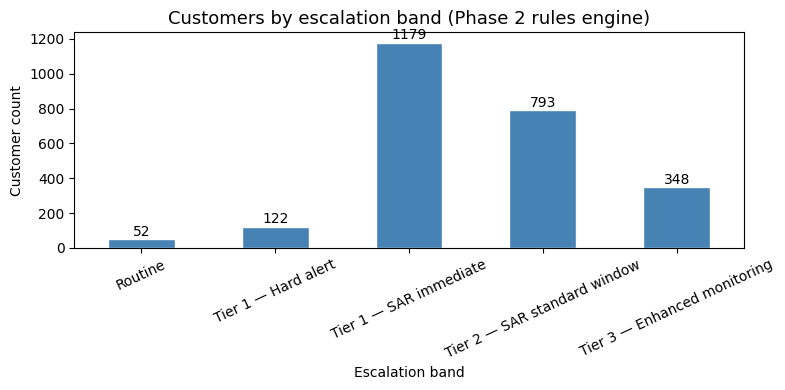

In [5]:
fires = ae.run_rules(txs, kyc, mer)
per   = ae.score(fires)

# Build alerts DataFrame (mirrors alerts_engine.main())
rows = [{
    "customer_id":     cid,
    "triggered_rules": "|".join(sorted(set(e["rules"]))),
    "total_score":     e["score"],
    "escalation_band": ae.assign_band(e),
    "hard_alert_flag": e["hard"],
} for cid, e in per.items()]

alerts = (pd.DataFrame(rows)
            .sort_values(["total_score", "hard_alert_flag"], ascending=[False, False])
            .reset_index(drop=True))

print("Escalation band distribution:")
band_counts = alerts["escalation_band"].value_counts()
print(band_counts.to_string())
print()

print("Top 15 scored customers:")
display(alerts.head(15))

# Bar chart of band counts
fig, ax = plt.subplots(figsize=(8, 4))
band_counts.sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Customers by escalation band (Phase 2 rules engine)", fontsize=13)
ax.set_xlabel("Escalation band")
ax.set_ylabel("Customer count")
ax.tick_params(axis="x", rotation=25)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## Section 5 — Isolation Forest: Independent Anomaly Detection

### The weak-label circularity problem

The XGBoost model in Phase 3 is trained on labels derived from the Phase 2 rules engine: a customer is labelled positive if their composite rule score exceeds a threshold, and negative if it falls below one. This creates a structural circularity: the model learns to approximate the rules it was labelled by, so when it assigns a high probability to a customer, that confidence reflects agreement with the rules — not an independent signal that the customer is suspicious.

In practice, this means XGBoost adds **intra-band tie-breaking and per-customer SHAP explainability**, but cannot surface customers whose behavior is anomalous in ways the rules do not capture.

### Isolation Forest as an independent check

`src/ml/isolation_forest.py` addresses this by training a fully unsupervised **Isolation Forest** model using only raw transaction features — no rules scores, no labels, no output from the alerts engine. The nine features are:

| Feature | Signal |
|---|---|
| `amount_brl` | Transaction magnitude |
| `tx_hour` | Time-of-day behaviour |
| `mcc_risk_enc` | Merchant category risk (encoded) |
| `country_risk_geo_enc` | Geographic risk (encoded) |
| `device_rooted_enc` | Rooted device indicator |
| `anon_enc` | Anonymisation type: None / VPN+Proxy / Tor |
| `tx_type_enc` | Rail: PIX / Card / Wire |
| `card_present_enc` | Card-not-present indicator |
| `auth_3ds_enc` | Missing 3DS authentication |

Features are averaged per customer before fitting. The resulting anomaly score is independent of the rules engine by construction. **When a customer ranks highly in both XGBoost and Isolation Forest, the two signals reinforce each other from different evidence bases** — strengthening the case for escalation. When they diverge (a customer is anomalous per IF but not per XGBoost), it may indicate a behavioral outlier not yet captured by the rule typologies.


Customers scored: 2500
Flagged as anomalous (top 5%): 125

Top 20 most anomalous customers:


,customer_id,anomaly_score,is_anomaly,rank
0,C100338,0.624548,True,1
1,C100377,0.614567,True,2
2,C101455,0.604703,True,3
3,C102393,0.602003,True,4
4,C101268,0.599792,True,5
5,C101679,0.598243,True,6
6,C100397,0.597846,True,7
7,C100369,0.596828,True,8
8,C100542,0.596521,True,9
9,C101942,0.595878,True,10


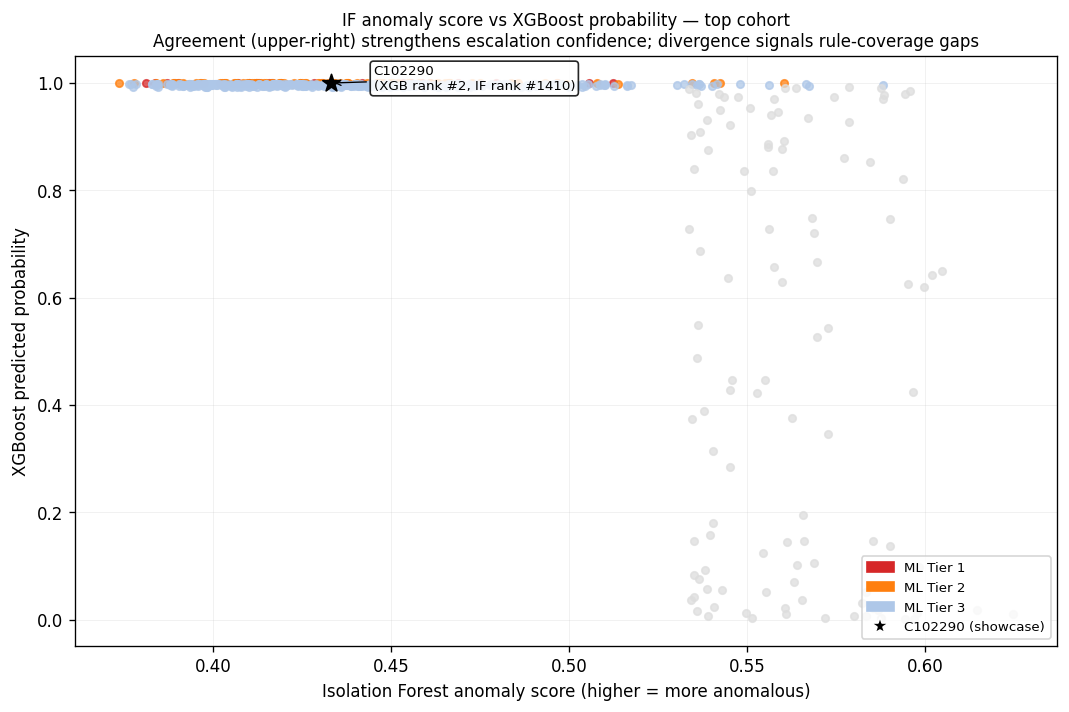


C102290 rankings:
  XGBoost probability rank : 2 / 2500
  Isolation Forest rank     : 1410 / 2500
  Interpretation: XGBoost flags C102290 based on rule-correlated features;
  IF ranks it mid-population, suggesting the risk comes from composite
  rule convergence rather than raw transaction-level anomaly.


In [6]:
import sys
sys.path.insert(0, str(ROOT / 'src' / 'ml'))
import isolation_forest as iso_mod
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display as ipy_display, Image as IpyImage
import io

# ── Run Isolation Forest ──────────────────────────────────────────────────────
if_scores, _ = iso_mod.run(txs, mer)

print(f"Customers scored: {len(if_scores)}")
print(f"Flagged as anomalous (top 5%): {if_scores.is_anomaly.sum()}")
print(f"\nTop 20 most anomalous customers:")
display(if_scores.head(20))

# ── Scatter: IF score vs XGBoost probability ──────────────────────────────────
ml_out = pd.read_csv(ROOT / 'outputs' / 'rankings' / 'ml_ranked_output.csv')

merged = if_scores.merge(
    ml_out[['customer_id', 'predicted_probability', 'predicted_band']],
    on='customer_id', how='inner'
)

# Focus on the top cohort: ML Tier 1/2/3 and top-5% IF anomalies
top_cohort = merged[
    merged.predicted_band.isin(['ML Tier 1', 'ML Tier 2', 'ML Tier 3']) |
    merged.is_anomaly
].copy()

band_colors = {
    'ML Tier 1': '#d62728',
    'ML Tier 2': '#ff7f0e',
    'ML Tier 3': '#aec7e8',
    'Routine':   '#dddddd',
}

fig, ax = plt.subplots(figsize=(9, 6))

for band, grp in top_cohort.groupby('predicted_band'):
    c = band_colors.get(band, '#cccccc')
    ax.scatter(grp.anomaly_score, grp.predicted_probability,
               c=c, s=20, alpha=0.75, label=band, zorder=2)

# Highlight C102290
subj = merged[merged.customer_id == 'C102290']
ax.scatter(subj.anomaly_score, subj.predicted_probability,
           c='black', s=120, zorder=5, marker='*')
ax.annotate(
    'C102290\n(XGB rank #2, IF rank #1410)',
    xy=(float(subj.anomaly_score.iloc[0]), float(subj.predicted_probability.iloc[0])),
    xytext=(float(subj.anomaly_score.iloc[0]) + 0.012, float(subj.predicted_probability.iloc[0]) - 0.012),
    fontsize=8, color='black',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', alpha=0.85),
)

ax.set_xlabel('Isolation Forest anomaly score (higher = more anomalous)', fontsize=10)
ax.set_ylabel('XGBoost predicted probability', fontsize=10)
ax.set_title(
    'IF anomaly score vs XGBoost probability — top cohort\n'
    'Agreement (upper-right) strengthens escalation confidence; '
    'divergence signals rule-coverage gaps',
    fontsize=10
)

handles = [mpatches.Patch(color=v, label=k) for k, v in band_colors.items() if k != 'Routine']
handles.append(plt.Line2D([0],[0], marker='*', color='w',
               markerfacecolor='black', markersize=11, label='C102290 (showcase)'))
ax.legend(handles=handles, fontsize=8, loc='lower right')
ax.grid(True, alpha=0.2, linewidth=0.5)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0)
ipy_display(IpyImage(data=buf.read(), format='png'))
plt.close(fig)

# Summary: where does C102290 sit in each ranking?
xgb_rank  = int(ml_out.reset_index().query("customer_id == 'C102290'").index[0]) + 1
if_rank   = int(if_scores[if_scores.customer_id == 'C102290']['rank'].values[0])
print(f"\nC102290 rankings:")
print(f"  XGBoost probability rank : {xgb_rank} / 2500")
print(f"  Isolation Forest rank     : {if_rank} / 2500")
print(f"  Interpretation: XGBoost flags C102290 based on rule-correlated features;")
print(f"  IF ranks it mid-population, suggesting the risk comes from composite")
print(f"  rule convergence rather than raw transaction-level anomaly.")


## Phase 3 — ML Prioritization Layer

**Why XGBoost:** Tabular data with mixed feature types, native missing-value handling, fast SHAP via TreeExplainer, and strong track record in financial-crime tooling. No deep learning — the dataset is 2,500 customers and operational explainability takes precedence over benchmark performance.

**Weak-label limitation:** Labels are derived from the Phase 2 rules engine (composite score ≥ 13 or hard alert = positive; score ≤ 4 = negative). The model approximates the rules in expectation — it cannot independently detect laundering not captured by the existing typologies. Its value is continuous ranking within score bands and SHAP-driven explainability for analyst triage.

**Precision vs. coverage trade-off:** Fixed-probability thresholds (e.g. p ≥ 0.75) place 1,439 customers in Tier 1 on this dataset — operationally meaningless. Percentile bands sized to analyst capacity (top 1% = 25 customers, top 5% = 100) give actionable queues at the cost of fixed recall. This is a deliberate calibration choice, not an architectural limitation.

Feature window: 2025-07-01 → 2025-10-31
Window transactions: 52,000



Features : 2500 customers × 39 features
Labels   : pos=557  neg=217  excluded=1726

Train+val : n=541  pos=389
Test      : n=233  pos=168

Training XGBoost...



Test metrics:
  PR-AUC           0.9981
  ROC-AUC          0.9947
  Precision@Top50  1.0000
  Recall@Top50     0.2976

Global SHAP summary (all 2,500 customers):


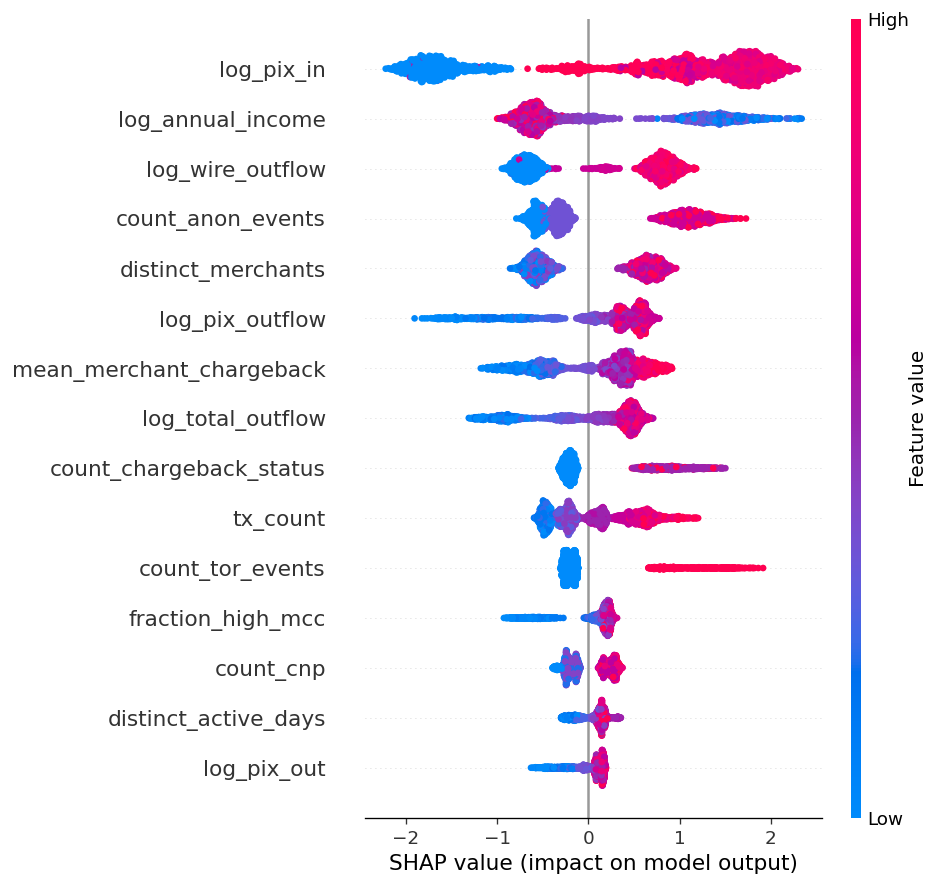

In [7]:
import ml_pipeline as mp
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    roc_curve, precision_recall_curve
)
from IPython.display import Image

RANDOM_STATE = 42

# Filter to feature/label window
txs["timestamp"] = pd.to_datetime(txs["timestamp"])
txs_window = txs[(txs.timestamp >= mp.FEAT_START) & (txs.timestamp < mp.FEAT_END)]
print(f"Feature window: {mp.FEAT_START.date()} → {(mp.FEAT_END - pd.Timedelta(days=1)).date()}")
print(f"Window transactions: {len(txs_window):,}")

# Build features and labels
X_all = mp.build_features(txs_window, kyc, mer)
lbl   = mp.build_labels(txs_window, kyc, mer)
print(f"\nFeatures : {X_all.shape[0]} customers × {X_all.shape[1]} features")
print(f"Labels   : pos={int(lbl.y.eq(1).sum())}  neg={int(lbl.y.eq(0).sum())}  excluded={int(lbl.y.isna().sum())}")

# Confined cohort for training (drop unlabeled mid-tier)
labeled = lbl.dropna(subset=["y"]).index
X = X_all.loc[labeled].astype(float)
y = lbl.loc[labeled, "y"].astype(int)

# Train-test split
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain+val : n={len(X_dev)}  pos={int(y_dev.sum())}")
print(f"Test      : n={len(X_test)}  pos={int(y_test.sum())}")

# Train model
print("\nTraining XGBoost...")
model = mp.train_xgb(X_dev, y_dev)

# Test metrics
test_probs = model.predict_proba(X_test)[:, 1]
pr_auc  = average_precision_score(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)
prec50, rec50 = mp.topk_metrics(y_test.values, test_probs, k=50)

print(f"\nTest metrics:")
print(f"  PR-AUC           {pr_auc:.4f}")
print(f"  ROC-AUC          {roc_auc:.4f}")
print(f"  Precision@Top50  {prec50:.4f}")
print(f"  Recall@Top50     {rec50:.4f}")

# ── ROC and PR curves side-by-side ────────────────────────────────────────────
fpr, tpr, _  = roc_curve(y_test, test_probs)
prec, rec, _ = precision_recall_curve(y_test, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, lw=2, color="steelblue", label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

axes[1].plot(rec, prec, lw=2, color="darkorange", label=f"PR-AUC = {pr_auc:.3f}")
baseline = float(y_test.mean())
axes[1].axhline(baseline, color="gray", linestyle="--", lw=1,
                label=f"Baseline (prevalence = {baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (test set)")
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

# ── SHAP summary (pre-generated) ──────────────────────────────────────────────
shap_img = ROOT / "outputs" / "figures" / "ml_shap_summary.png"
print("\nGlobal SHAP summary (all 2,500 customers):")
display(Image(filename=str(shap_img), width=800))

# ── Feature importance from model.feature_importances_ ───────────────────────
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp["feature"].iloc[::-1].values,
        feat_imp["importance"].iloc[::-1].values,
        color="steelblue", edgecolor="white")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 15 features — XGBoost gain importance")
plt.tight_layout()
plt.show()

## Section 6 — C102290 end-to-end case

End-to-end review of C102290 — the primary SAR showcase subject.

In [8]:
SUBJECT = "C102290"

# ── Rules fired ───────────────────────────────────────────────────────────────
subj_alert = alerts[alerts.customer_id == SUBJECT]
print(f"Rules fired for {SUBJECT}:")
display(subj_alert[["customer_id", "triggered_rules", "total_score", "escalation_band", "hard_alert_flag"]])
print()

# ── ML probability and band (from saved output) ───────────────────────────────
ml_out  = pd.read_csv(ROOT / "outputs" / "rankings" / "ml_ranked_output.csv")
subj_ml = ml_out[ml_out.customer_id == SUBJECT]
print(f"ML output for {SUBJECT}:")
display(subj_ml[["customer_id", "predicted_probability", "predicted_band",
                  "actual_label", "top_shap_driver_1", "top_shap_driver_2", "top_shap_driver_3"]])
print()

# ── Key metrics summary ───────────────────────────────────────────────────────
kyc_row  = kyc_idx.loc[SUBJECT]
subj_txs = cust_txs[cust_txs.sender_id == SUBJECT]

declared_annual  = 11_177.0
declared_monthly = declared_annual / 12
total_outflow    = subj_txs["amount_brl"].sum()
income_multiple  = total_outflow / declared_monthly

# PIX passthrough
subj_pix_out = txs[(txs.pix_flow == "cash_out")  & (txs.sender_id == SUBJECT)]["amount_brl"].sum()
subj_pix_in  = txs[(txs.pix_flow == "cash_in")   & (txs.receiver_id == SUBJECT)]["amount_brl"].sum()
pix_passthru_pct = (subj_pix_out / subj_pix_in * 100) if subj_pix_in > 0 else float("inf")

# Anonymization events
anon_events = int(subj_txs[subj_txs.ip_proxy_vpn_tor.isin(["Tor", "VPN", "Proxy"])].shape[0])

summary = {
    "Declared annual income (R$)":        f"{declared_annual:,.0f}",
    "Monthly income (R$)":                f"{declared_monthly:,.0f}",
    "Total outflow (R$)":                 f"{total_outflow:,.0f}",
    "Income multiple":                    f"{income_multiple:.0f}x",
    "PIX passthrough (%)": f"{pix_passthru_pct:,.0f}%",
    "Anonymization events (Tor/VPN/Proxy)": anon_events,
    "KYC risk score":                     kyc_row["kyc_risk_score"],
    "PEP status":                         kyc_row["pep"],
}

print(f"Key risk metrics — {SUBJECT}:")
display(pd.DataFrame.from_dict(summary, orient="index", columns=["Value"]))
print()

# ── First 60 lines of SAR ─────────────────────────────────────────────────────
sar_path  = ROOT / "docs" / "phase1" / "SAR-2025-C102290-01.md"
sar_lines = sar_path.read_text().splitlines()[:60]
print(f"\n--- {sar_path.name} (first 60 lines) ---\n")
print("\n".join(sar_lines))

Rules fired for C102290:


,customer_id,triggered_rules,total_score,escalation_band,hard_alert_flag
1,C102290,R01|R03_HIGH|R04|R05_TOR|R09|R10|R11|R15|R17|R...,24,Tier 1 — SAR immediate,False



ML output for C102290:


,customer_id,predicted_probability,predicted_band,actual_label,top_shap_driver_1,top_shap_driver_2,top_shap_driver_3
1,C102290,0.9998,ML Tier 1,1,log_pix_in,log_annual_income,count_anon_events



Key risk metrics — C102290:


,Value
Declared annual income (R$),"11,177"
Monthly income (R$),931
Total outflow (R$),"134,319"
Income multiple,144x
PIX passthrough (%),"2,013%"
Anonymization events (Tor/VPN/Proxy),3
KYC risk score,98
PEP status,Yes




--- SAR-2025-C102290-01.md (first 60 lines) ---

# SUSPICIOUS ACTIVITY REPORT (SAR)
**Internal Reference:** SAR-2025-C102290-01
**Filing Institution:** CloudWalk INC — AML/FT Compliance Unit
**Prepared by:** Senior AML Investigator
**Date of Issue:** 2025-11-15
**Classification:** Internal — Compliance Restricted

---

## 1. CASE IDENTIFICATION

| Field | Detail |
|---|---|
| **Primary Subject** | C102290 |
| **Subject Name** | [Redacted] |
| **Declared Occupation** | Driver |
| **Declared Annual Income** | R$11,177 (≈ R$931/month) |
| **PEP Status** | Yes |
| **KYC Risk Score** | 98 / 100 |
| **Risk Rating (categorical)** | Medium ⚠ (inconsistent with PEP/score — see Section 3) |
| **KYC Tier** | L1 ⚠ (lowest verification tier — inconsistent with PEP status) |
| **Sanctions Screening** | No direct hit |
| **Review Period** | 2025-07-01 to 2025-10-31 |
| **Transaction Rails Observed** | PIX (16), Card (10), Wire (1) |
| **Total Outflow Volume** | R$134,319 |
| **Total Inflow Volume (

## Section 7 — Entity Graph: C102290 cluster

### Why merchant convergence is an AML red flag

Merchant convergence occurs when two or more customers who were flagged **independently** — on the basis of their own activity, with no prior link assumed — are found to share the same receiving merchants. This matters for two reasons:

1. **It is not explained by coincidence at scale.** A platform with 1,000 merchants and 2,500 customers has a low baseline probability that two high-risk customers independently route funds to the same obscure merchant. When it happens across multiple merchants simultaneously (here: M200460 and M200186), the probability of independence drops sharply.

2. **It suggests coordinated layering, not parallel anomalies.** In classic layering, multiple placement accounts feed funds upward through shared distribution nodes — merchants, aggregators, or wallets — before integration. The shared merchant acts as a convergence point that links otherwise unconnected sources. This pattern is captured by rule R20 (Merchant Convergence) and elevates both subjects from individual SARs to a potential network SAR.

The graph below shows C102290 and C100880 as independently flagged customers (red), with directed edges to the two shared merchants (blue). Edge width is proportional to transaction amount. Both customers reached these merchants via different rails and on different dates — the convergence is structural, not transactional coincidence.


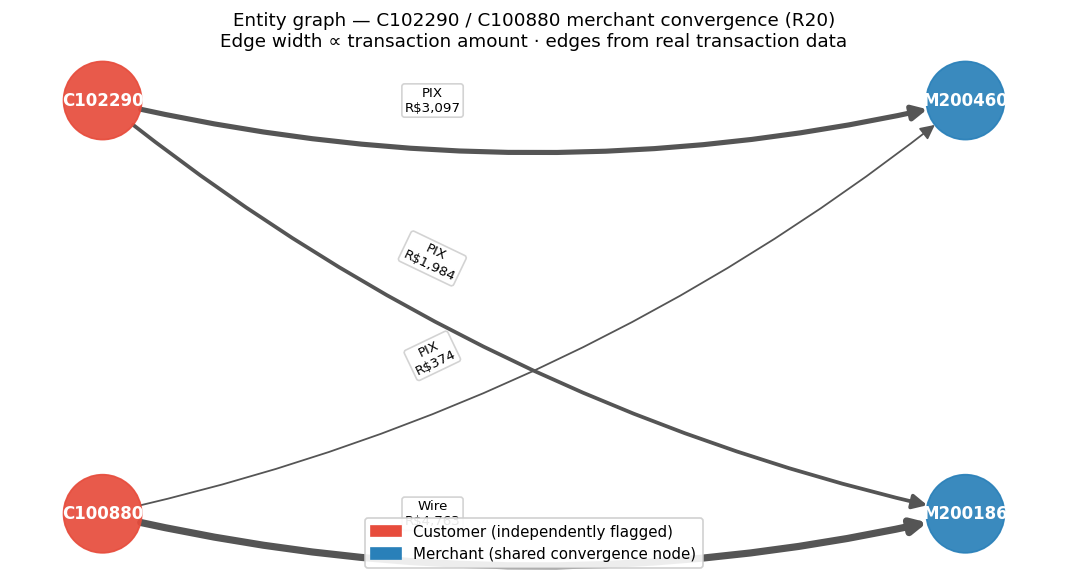


Edge summary:
                       txn_count  Total (R$)  rail
sender_id receiver_id                             
C100880   M200186              1     4763.31  Wire
          M200460              1      374.38   PIX
C102290   M200186              1     1983.85   PIX
          M200460              1     3097.29   PIX


In [9]:
import networkx as nx
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display as ipy_display, Image as IpyImage
import io, base64

# ── Build graph from real transaction data ────────────────────────────────────
subjects  = ['C102290', 'C100880']
merchants = ['M200460', 'M200186']

sub_txs = txs[
    txs.sender_id.isin(subjects) & txs.receiver_id.isin(merchants)
][['sender_id', 'receiver_id', 'amount_brl', 'transaction_type']].copy()

G = nx.DiGraph()
G.add_nodes_from(subjects,  node_type='customer')
G.add_nodes_from(merchants, node_type='merchant')

for _, row in sub_txs.iterrows():
    G.add_edge(
        row['sender_id'], row['receiver_id'],
        amount=row['amount_brl'],
        rail=row['transaction_type'],
    )

# ── Layout ────────────────────────────────────────────────────────────────────
pos = {
    'C102290': (0.0,  0.6),
    'C100880': (0.0, -0.6),
    'M200460': (1.0,  0.6),
    'M200186': (1.0, -0.6),
}

node_colors = [
    '#e74c3c' if G.nodes[n]['node_type'] == 'customer' else '#2980b9'
    for n in G.nodes()
]

max_amount = max(d['amount'] for _, _, d in G.edges(data=True))
edge_widths = [3.5 * (d['amount'] / max_amount) + 0.8 for _, _, d in G.edges(data=True)]
edge_labels = {
    (u, v): f"{d['rail']}\nR${d['amount']:,.0f}"
    for u, v, d in G.edges(data=True)
}

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, ax=ax, alpha=0.92)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color='#555555',
    arrows=True, arrowsize=18,
    connectionstyle='arc3,rad=0.12', ax=ax,
    node_size=2200,
)
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_size=8, label_pos=0.38, ax=ax,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#cccccc', alpha=0.85),
)

legend = [
    mpatches.Patch(color='#e74c3c', label='Customer (independently flagged)'),
    mpatches.Patch(color='#2980b9', label='Merchant (shared convergence node)'),
]
ax.legend(handles=legend, loc='lower center', fontsize=9, framealpha=0.9)
ax.set_title(
    'Entity graph — C102290 / C100880 merchant convergence (R20)\n'
    'Edge width ∝ transaction amount · edges from real transaction data',
    fontsize=11,
)
ax.axis('off')
plt.tight_layout()

# Embed PNG as base64 so it appears in the notebook output
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0)
ipy_display(IpyImage(data=buf.read(), format='png'))
plt.close(fig)

print('\nEdge summary:')
print(sub_txs.groupby(['sender_id', 'receiver_id']).agg(
    txn_count=('amount_brl', 'size'),
    total_brl=('amount_brl', 'sum'),
    rail=('transaction_type', 'first'),
).rename(columns={'total_brl': 'Total (R$)'}).to_string())
